In [25]:
import pandas as pd
import keras
import tensorflow
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from itertools import combinations
from sklearn.preprocessing import FunctionTransformer, normalize


In [26]:
df = pd.read_excel('amostras_inferenciadas.xlsx', engine='openpyxl', sheet_name='18_02_2020')

In [27]:
df.head(5)

,ID,AT,AC,OFERTA,VC,intervalo,UNI,"UNIx0,8 + ITBI","UNIx0,9 + ITBI",VP,...,ZH,PAV,UNI-PRA,CC,TIPO,END,BAIRRO,FONTE / IF,longitude,latitude
0,1,700.0,560,2100000.0,1.481028e+06,501-700,884.0,707.2,795.6,1,...,4,1,145.3827,1,GALPÃO,"AV VEREADOR DA COSTA RIOS, 1111",CENTRO,CIOFFI IMOVEIS,-45.930455,-22.245445
1,2,380.0,253,1100000.0,6.301932e+05,1001-1500,1236.0,988.8,1112.4,0,...,6,1,48.4600,0,RESIDENCIAL,"RUA PEDRO CALDAS REBELLO, 290",SANTO IVO,CIOFFI IMOVEIS,-45.923179,-22.219603
2,4,450.0,350,1900000.0,1.268652e+06,1001-1500,1403.0,1122.4,1262.7,0,...,6,1,672.0000,0,RESIDENCIAL,"RUA PROF MARIA FERNANDES CASCALLI, 105",FATIMA I,CIOFFI IMOVEIS,-45.915588,-22.221595
3,5,270.0,140,650000.0,3.677250e+05,701-1000,1045.0,836.0,940.5,0,...,5,1,116.2800,0,RESIDENCIAL,"RUA MARIO DE FREITAS CARDOSO, 20",POUSADA DOS CAMPOS III,CIOFFI IMOVEIS,-45.916247,-22.210899
4,6,300.0,0,200000.0,0.000000e+00,701-1000,667.0,533.6,600.3,0,...,5,1,62.0100,0,TERRENO,"RUA BENONE FERREIRA DA COSTA, AO LADO DO 205",NOSSA SENHORA DO PILAR II,CIOFFI IMOVEIS,-45.935582,-22.213639


In [28]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target')
df['tipo'] = df['tipo'].str.replace(' ', '').str.lower()

In [29]:
df = pd.get_dummies(df, columns=['tipo'], dtype=int, drop_first=True)
df.columns

Index(['id', 'at', 'ac', 'oferta', 'vc', 'intervalo', 'uni', 'unix0,8_+_itbi',
       'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7',
       'z8', 'z9', 'itbi/of', 'zh', 'pav', 'uni-pra', 'cc', 'end', 'bairro',
       'fonte_/_if', 'longitude', 'latitude', 'tipo_casa', 'tipo_comercial',
       'tipo_galpão', 'tipo_predio', 'tipo_residencial', 'tipo_terreno'],
      dtype='object')

In [30]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target').str.replace('ã', 'a')
df = df[['at', 'ac', 'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4',
         'z5', 'z6', 'z7', 'z8', 'z9', 'pav', 'cc', 'longitude', 'latitude',
       'tipo_casa', 'tipo_comercial',  'tipo_galpao', 'tipo_predio',
        'tipo_residencial', 'tipo_terreno']]
#rename cc to corredor_comercial
df = df.rename(columns={'cc': 'corredor_comercial', 'vp': 'via_principal', 'vs': 'via_secundaria', 'ov': 'outros_vias'})


In [31]:
# transforma pav 2 em 1 
df['pav'].loc[df['pav'] == 2] = 1

# converte lat e long para utm
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs='EPSG:4326')
gdf = gdf.to_crs(epsg=31983)  # SIR
df['x'] = gdf.geometry.x
df['y'] = gdf.geometry.y
df = df.drop(columns=['longitude', 'latitude'])

/tmp/ipykernel_1767/2086759106.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pav'].loc[df['pav'] == 2] = 1
/tmp/ipykernel_1767/2086759106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [32]:
kml_path = "zoneamento.kml"

gdf_kml = gpd.read_file(kml_path, driver='KML')

print(gdf_kml.head())


  Name Description                                           geometry
0                   MULTILINESTRING Z ((-45.9722 -22.24319 0, -45....


/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'zoneamento.kml': 'dissolved' (default), 'puparetificadissolvido', 'zepam1of', 'zep', 'zeep', 'zoneamentodissolvido'. Specify layer parameter to avoid this warning.
  result = read_func(


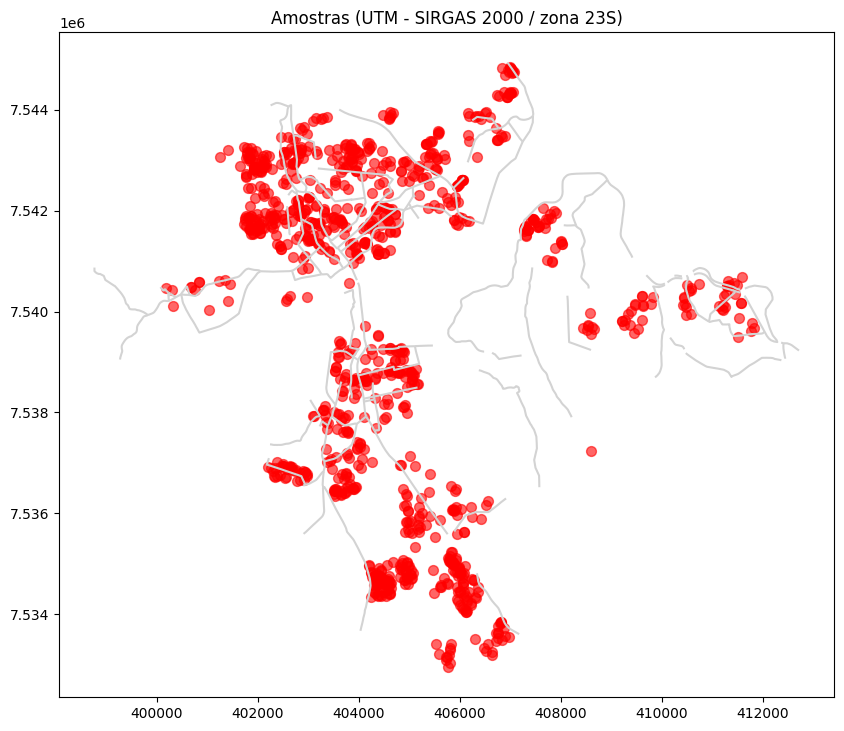

In [33]:
geometry = [Point(x, y) for x, y in zip(df['x'], df['y'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:31983")  # usa o mesmo CRS do SIRGAS UTM

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_kml.to_crs(epsg=31983).plot(ax=ax, color='lightgrey', edgecolor='black')  
gdf_points.plot(ax=ax, color='red', markersize=50, alpha=0.6)

plt.title("Amostras (UTM - SIRGAS 2000 / zona 23S)")
plt.show()

In [34]:
#find value that contains '-'
df[df.isin(['-']).any(axis=1)]

,at,ac,target,via_principal,via_secundaria,outros_vias,z1,z2,z3,z4,...,pav,corredor_comercial,tipo_casa,tipo_comercial,tipo_galpao,tipo_predio,tipo_residencial,tipo_terreno,x,y
31,1008.0,200,198.000000,0,0,1,0,0,0,0,...,-,0,0,0,0,0,1,0,408602.619818,7.537235e+06
107,627.0,0,186.300000,0,1,0,0,1,0,0,...,-,0,0,0,0,0,0,1,406302.262338,7.533502e+06
131,600.0,0,202.500000,0,0,1,0,1,0,0,...,-,0,0,0,0,0,0,1,405768.583724,7.532956e+06
132,600.0,0,180.000000,0,0,1,0,1,0,0,...,-,0,0,0,0,0,0,1,405726.571462,7.533163e+06
479,240.0,-,300.000000,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,1,408512.155746,7.539639e+06
482,1500.0,-,147.000000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409607.527057,7.540317e+06
483,800.0,-,281.250000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409624.157716,7.540109e+06
487,700.0,-,141.428571,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409333.040653,7.539954e+06
488,800.0,-,337.500000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409384.917407,7.540012e+06
492,200.0,-,292.500000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,405908.494981,7.534833e+06


In [35]:
#replace values that have "-" with null
df.replace("-", pd.NA, inplace=True)
df.dropna(inplace=True)
df['pav'] = df['pav'].astype(int)
df.loc[df['pav'] == 2, 'pav'] = 1

In [36]:
df.columns

Index(['at', 'ac', 'target', 'via_principal', 'via_secundaria', 'outros_vias',
       'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'pav',
       'corredor_comercial', 'tipo_casa', 'tipo_comercial', 'tipo_galpao',
       'tipo_predio', 'tipo_residencial', 'tipo_terreno', 'x', 'y'],
      dtype='object')

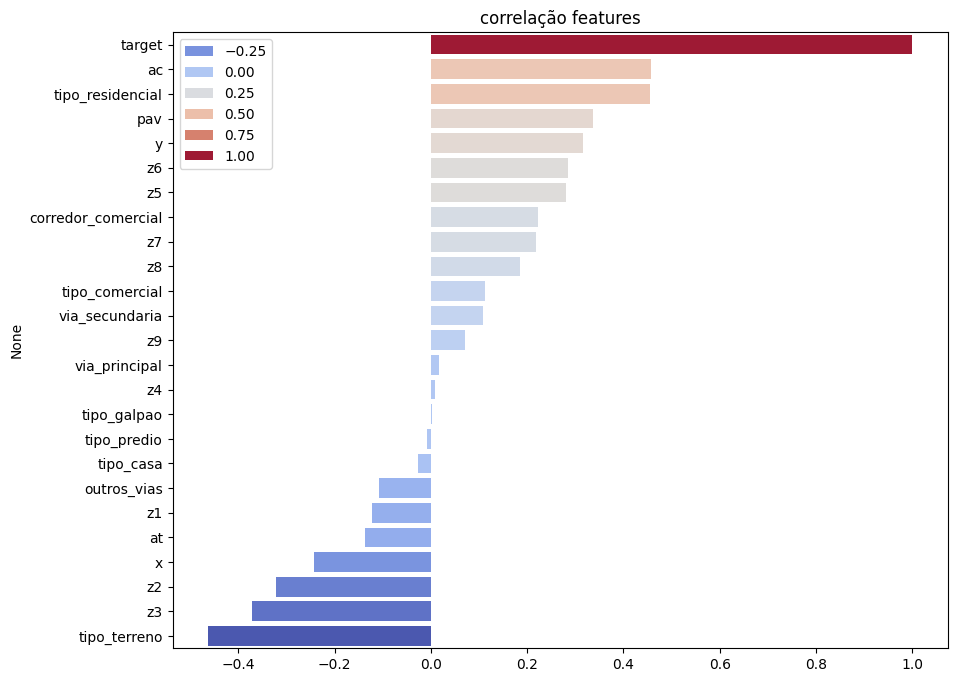

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_target = df.corr(method='spearman')['target'].sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.values, palette='coolwarm')
plt.title("correlação features")
plt.show()

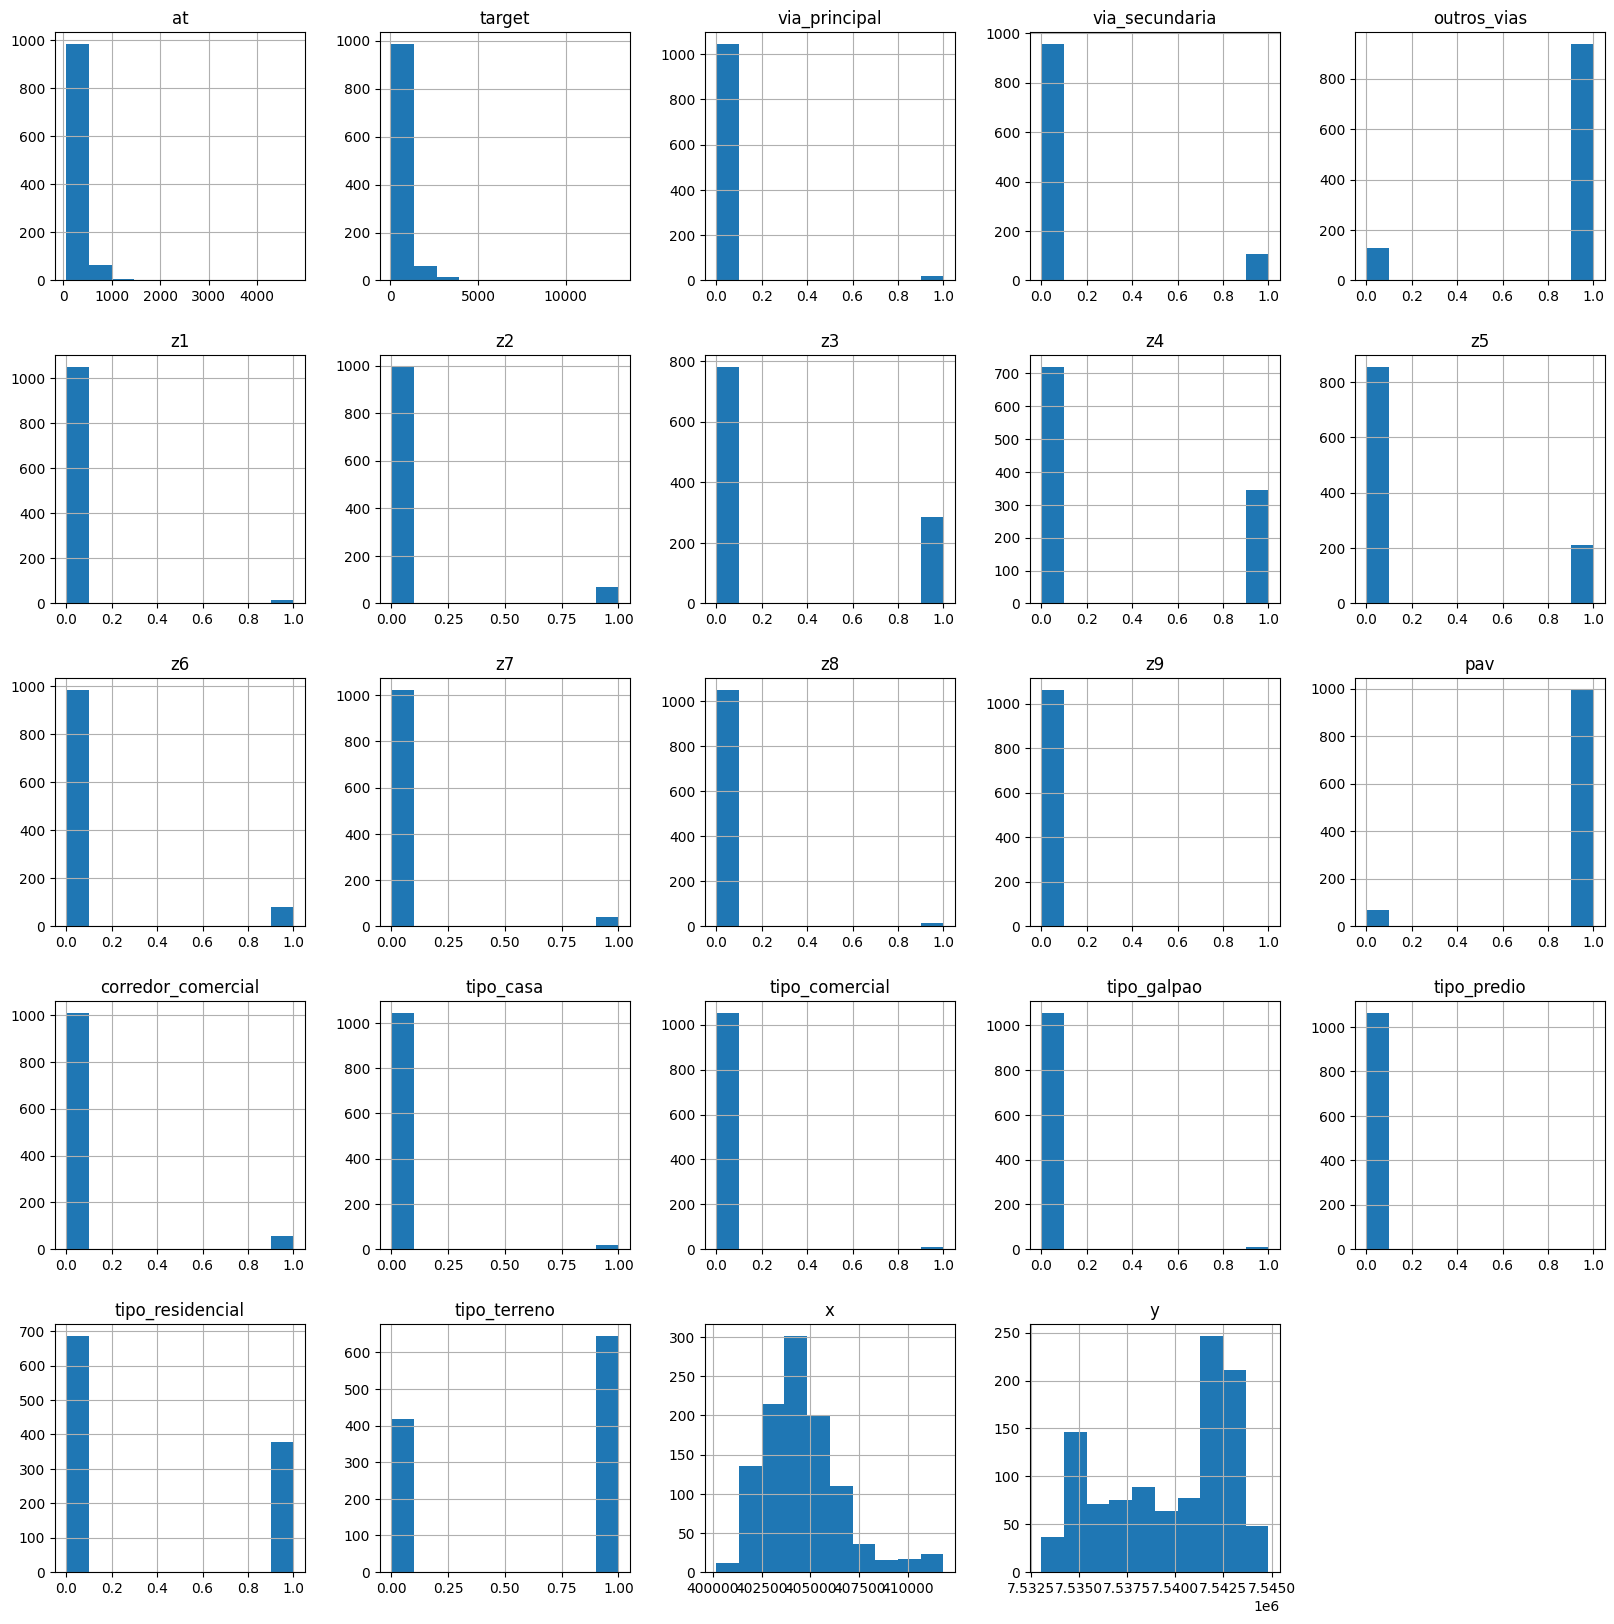

In [38]:
# plot histogram of each feature with a redline of the curve
df.hist(figsize=(20,20))
plt.show()

In [39]:
#normalize with log
log_df = df.copy()
log_df[log_df.columns] = log_df[log_df.columns].astype(float).apply(lambda x: np.log1p(x + 1))

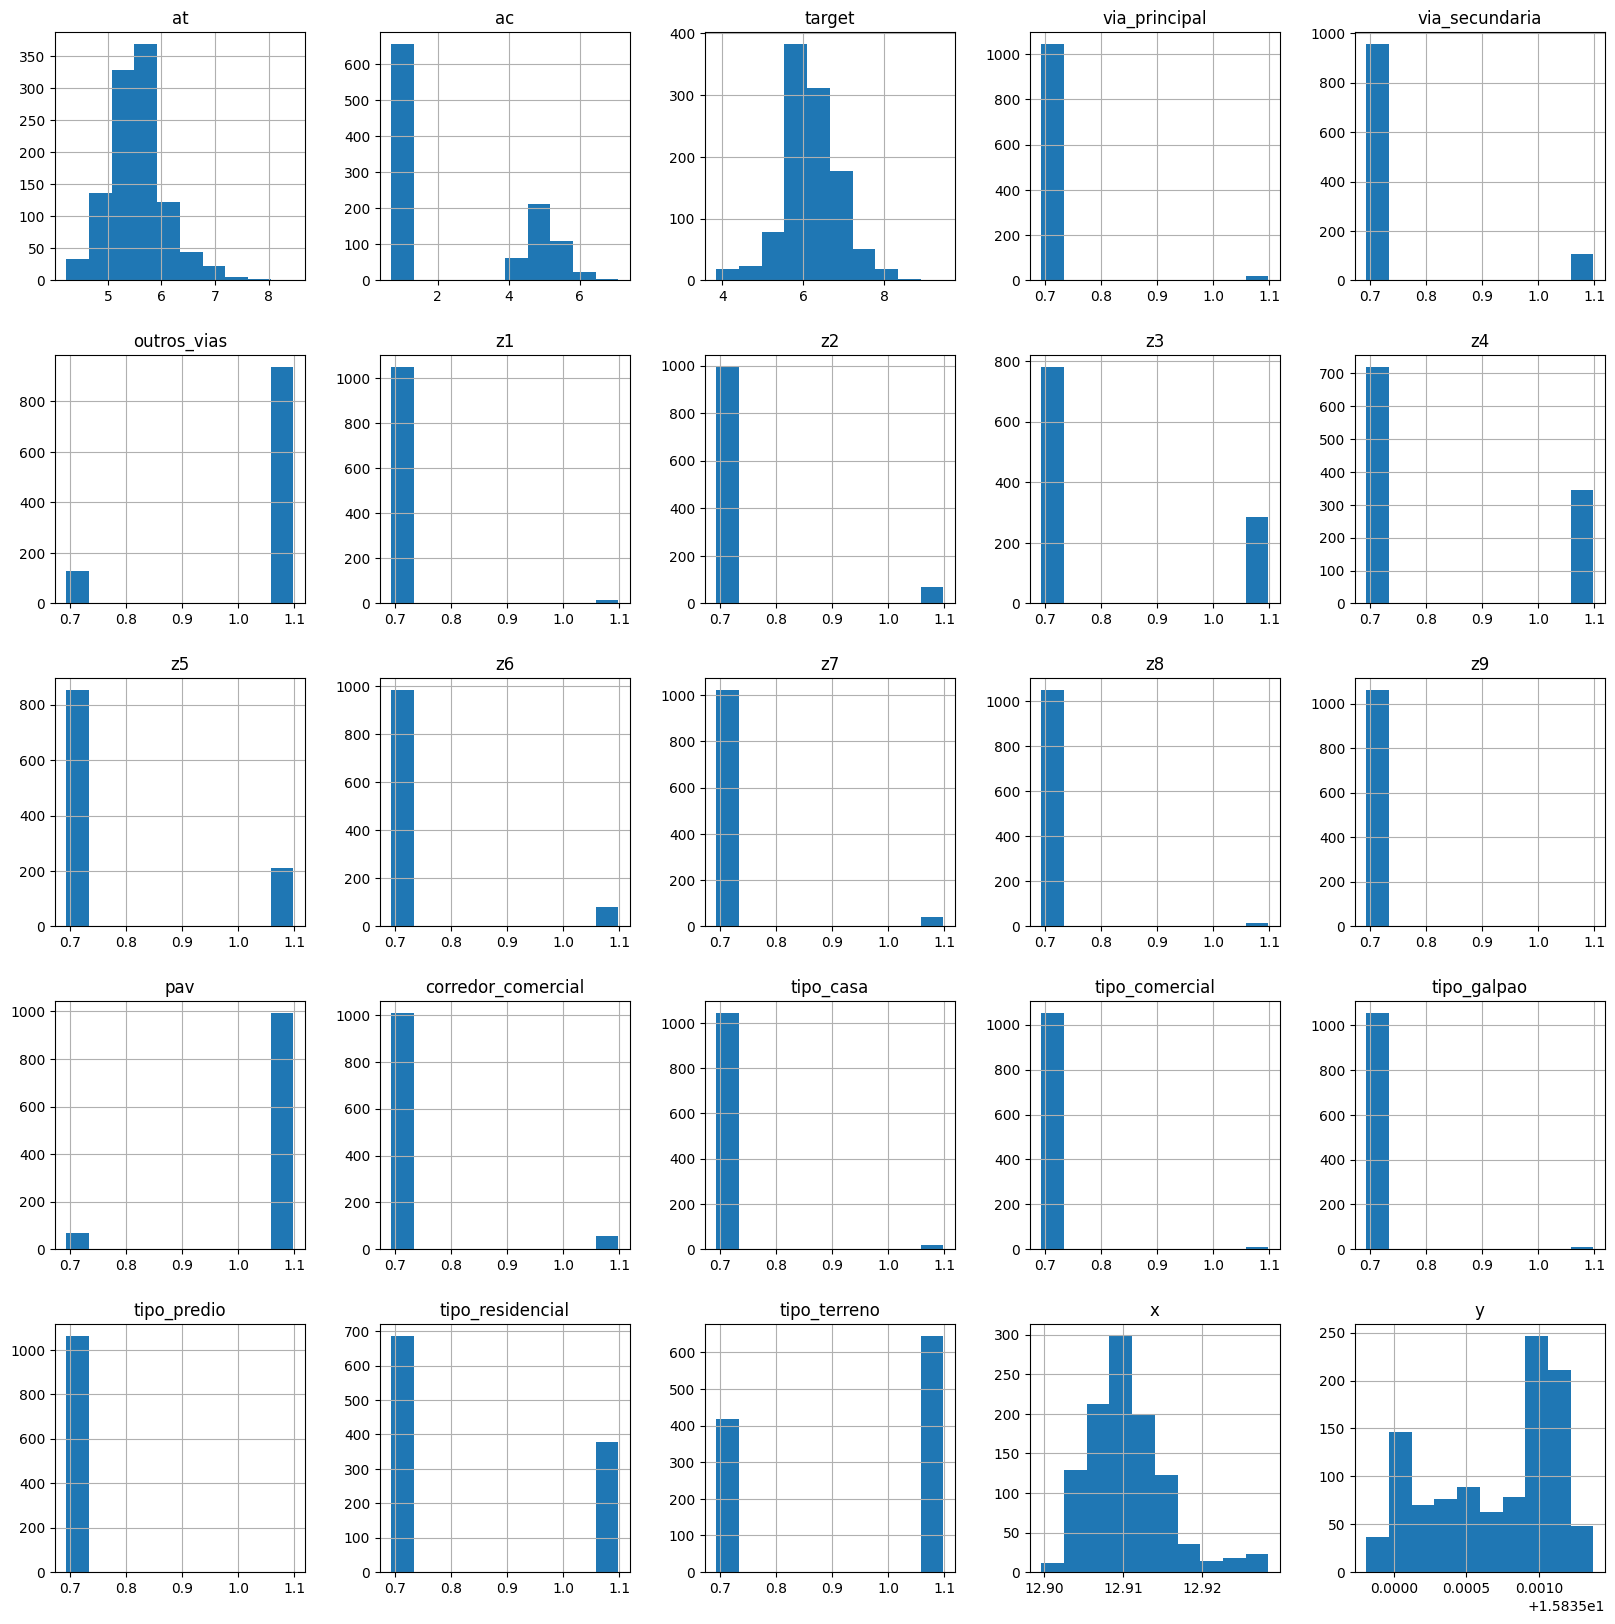

In [40]:
log_df.hist(figsize=(20,20))
plt.show()